In [357]:
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import scipy as sp
import seaborn as sns
import xarray as xr

# Dirichlet process mixtures - CDFs

https://www.pymc.io/projects/examples/en/latest/mixture_models/dp_mix.html

Probability distribution P on a set omega such that P(omega) = 1

Dirichlet process P ~ DP(alpha, P_0) for a set of 1 to n

P(S_i) ~ Dir(alpha*P_0(S_i))

alpha = precision parameter > 0

As alpha approaches infinity, the distribution approaches the base distribution. In this case, the base distribution is P0, a normal distribution with mean=0, stdev=1

P0 = N(0,1)

A large 𝛼 means you expect many components, and the model will more readily add new clusters. A small 𝛼 implies that you expect the data to be well-represented by a small number of clusters. 

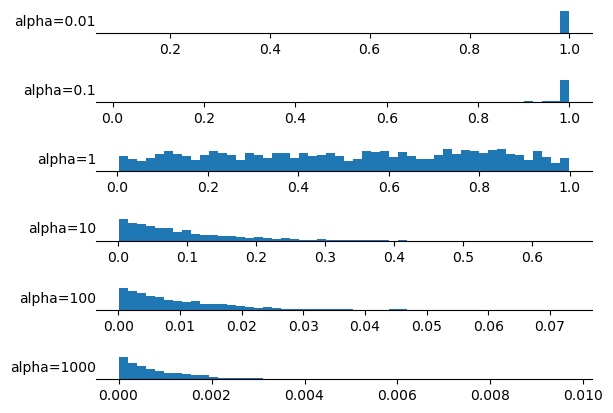

In [376]:
#testing different alpha values to see what beta values we get

alphas = [0.01, 0.1, 1, 10, 100, 1000]
fig, axes = plt.subplots(len(alphas), 1, sharex=False, gridspec_kw=dict(hspace=2))

for i, alpha in enumerate(alphas):
    ax = axes[i]
    data = sp.stats.beta.rvs(1, alpha, size=1_000)
    
    ax.hist(data, bins=50)
    ax.text(x=0, y=0.5, s=f'alpha={alpha}', ha='right', va='center', transform=ax.transAxes)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.get_yaxis().set_visible(False)

In [377]:
N = 50
K = 100

alpha = 200
P0 = sp.stats.norm

Draw and plot samples from stick-breaking process. Stick-breaking gives explicit construction of weights u_i and samples w_i above that is straightforward to sample from

In [378]:
beta = sp.stats.beta.rvs(1, alpha, size=(N, K))

w = np.empty_like(beta)
w[:, 0] = beta[:, 0]
w[:, 1:] = beta[:, 1:] * (1 - beta[:, :-1]).cumprod(axis=1)

for i in range(len(w)):
    w[i] /= sum(w[i])

omega = P0.rvs(size=(N, K))

x_plot = xr.DataArray(np.linspace(-3, 3, 200), dims=["plot"])

sample_cdfs = (w[..., np.newaxis] * np.less.outer(omega, x_plot.values)).sum(axis=1)

If K isn't high enough, the plot for the DP sample CDFs is well below the Base CDF, so they don't end up equaling one. Plus there's a spread of what the final value is for each of the sample CDFs. Can't figure out why that is.

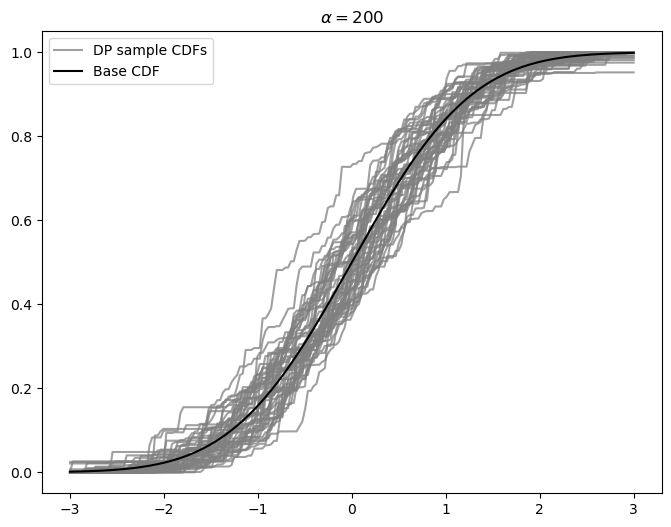

In [379]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x_plot, sample_cdfs[0], c="gray", alpha=0.75, label="DP sample CDFs")
ax.plot(x_plot, sample_cdfs[1:].T, c="gray", alpha=0.75)
ax.plot(x_plot, P0.cdf(x_plot), c="k", label="Base CDF")

ax.set_title(rf"$\alpha = {alpha}$")
ax.legend(loc=2);

# Dirichlet process mixtures

Dirichlet process mixture uses component densities from a parametric family and represents the mixture weights as a Dirichlet process.

P_0 is a measure on the parameter space Omega

Example where we simulate draws from a Dirichlet process mixture with
- alpha=2
- theta ~ N(0,1)
- x | theta ~ N(theta, (0.3)^2)


As K increases, the DP plots get closer and closer to P0. Same with alpha, but it tops out at alpha around 100. K seems to be more important to get a closer approximation.

In [514]:
N = 100 #number of sample distributions created
alpha = 100 # smaller alpha means less of the stick is left for subsequent values, so distributions are more concentrated
K = 100 #number of stick breaks
K = int(np.round(alpha*np.log(N),0)) #expected number of components that contribute non-negligible mass to mixture

P0 = sp.stats.norm
f = lambda x, theta: sp.stats.norm.pdf(x, theta, 0.3)


In [423]:
beta = sp.stats.beta.rvs(1, alpha, size=(N, K))
w = np.empty_like(beta)
w[:, 0] = beta[:, 0]
w[:, 1:] = beta[:, 1:] * (1 - beta[:, :-1]).cumprod(axis=1) #cumulative product

for i in range(len(w)):
    w[i] /= sum(w[i])


theta = P0.rvs(size=(N, K))

dpm_pdf_components = f(x_plot, theta[..., np.newaxis])
dpm_pdfs = (w[..., np.newaxis] * dpm_pdf_components).sum(axis=1)

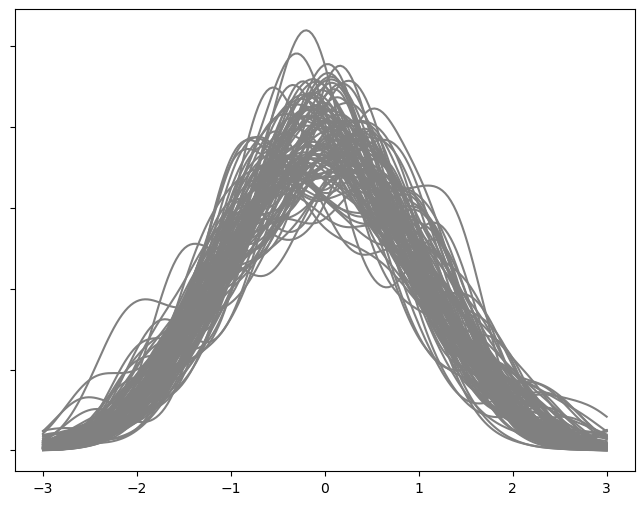

In [424]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x_plot, dpm_pdfs.T, c="gray", alpha=1)

ax.set_yticklabels([]);

Focus on single mixture and decompose it into its individual weighted mixture components

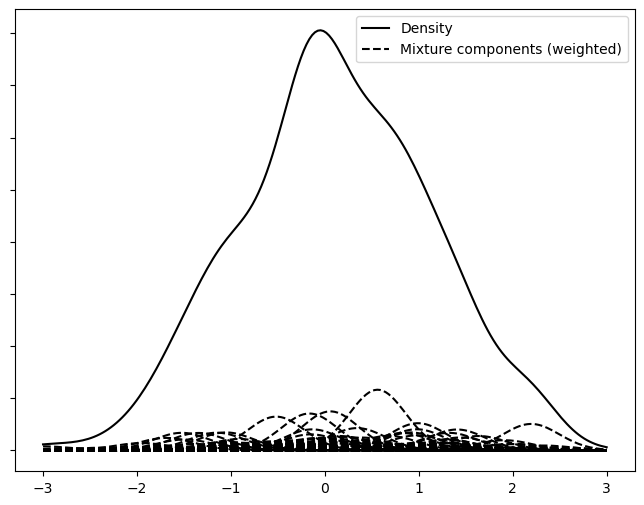

In [267]:
fig, ax = plt.subplots(figsize=(8, 6))

ix = 1

ax.plot(x_plot, dpm_pdfs[ix], c="k", label="Density")
ax.plot(
    x_plot,
    (w[..., np.newaxis] * dpm_pdf_components)[ix, 0],
    "--",
    c="k",
    label="Mixture components (weighted)",
)
ax.plot(x_plot, (w[..., np.newaxis] * dpm_pdf_components)[ix].T, "--", c="k")

ax.set_yticklabels([])
ax.legend(loc=1);

Our first example uses a Dirichlet process mixture to estimate the density of waiting times between eruptions of the Old Faithful geyser in Yellowstone National Park.Our first example uses a Dirichlet process mixture to estimate the density of waiting times between eruptions of the Old Faithful geyser in Yellowstone National Park.

# Textbook example as is
https://www.pymc.io/projects/examples/en/latest/mixture_models/dp_mix.html

In [440]:
try:
    old_faithful_df = pd.read_csv(os.path.join("..", "data", "old_faithful.csv"))
except FileNotFoundError:
    old_faithful_df = pd.read_csv(pm.get_data("old_faithful.csv"))

For convenience in specifying the prior, we standardize the waiting time between eruptions.

In [450]:
old_faithful_df["std_waiting"] = (
    old_faithful_df.waiting - old_faithful_df.waiting.mean()
) / old_faithful_df.waiting.std()

old_faithful_df.head()

,eruptions,waiting,std_waiting
0,3.600,79,0.596025
1,1.800,54,-1.242890
2,3.333,74,0.228242
3,2.283,62,-0.654437
4,4.533,85,1.037364


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

n_bins = 20
ax.hist(old_faithful_df.std_waiting, bins=n_bins, color="C0", lw=0, alpha=0.5)

ax.set_xlabel("Standardized waiting time between eruptions")
ax.set_ylabel("Number of eruptions");

- finite breaks are okay (don't need to go indefinitely)
- figure out how many mixture components contribute non-negligible mass to mixture
- expected components approaches alpha*log(N)
- figure out value of alpha

In [452]:
N = old_faithful_df.shape[0]
K = 30

In [453]:
def stick_breaking(beta):
    portion_remaining = pt.concatenate([[1], pt.extra_ops.cumprod(1 - beta)[:-1]])
    return beta * portion_remaining

In [454]:
with pm.Model(coords={"component": np.arange(K), "obs_id": np.arange(N)}) as model:
    #prior on alpha (number of components) - we don't know how concentrated it should be
    alpha = pm.Gamma("alpha", 1.0, 1.0)
    
    # stick-breaking calculation
    beta = pm.Beta("beta", 1.0, alpha, dims="component")
    w = pm.Deterministic("w", stick_breaking(beta), dims="component")

    #prior on tau, related to concentration of components
    tau = pm.Gamma("tau", 1.0, 1.0, dims="component")
    lambda_ = pm.Gamma("lambda_", 10.0, 1.0, dims="component")
    
    #base distribution
    mu = pm.Normal("mu", 0, tau=lambda_ * tau, dims="component")
    
    # final mixture, where each component has precision lambda*tau
    # samples from components reflect observed data
    obs = pm.NormalMixture(
        "obs", w, mu, tau=lambda_ * tau, observed=old_faithful_df.std_waiting.values, dims="obs_id"
    )

In [455]:
#takes ~30 minutes to run
with model:
    trace = pm.sample(
        tune=2500,
        init="advi",
        target_accept=0.975,
        random_seed=RANDOM_SEED,
    )

Auto-assigning NUTS sampler...
Initializing NUTS using advi...


Output()

Convergence achieved at 9800
Interrupted at 9,799 [4%]: Average Loss = 495.41
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, tau, lambda_, mu]


Output()

Sampling 4 chains for 2_500 tune and 1_000 draw iterations (10_000 + 4_000 draws total) took 1934 seconds.
There were 66 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


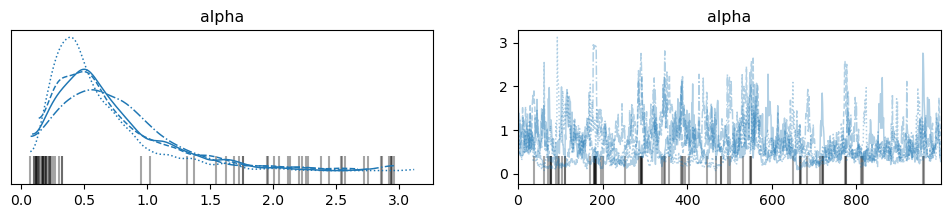

In [456]:
az.plot_trace(trace, var_names=["alpha"]);

To verify that truncation is not biasing our results, we plot the posterior expected mixture weight of each component.

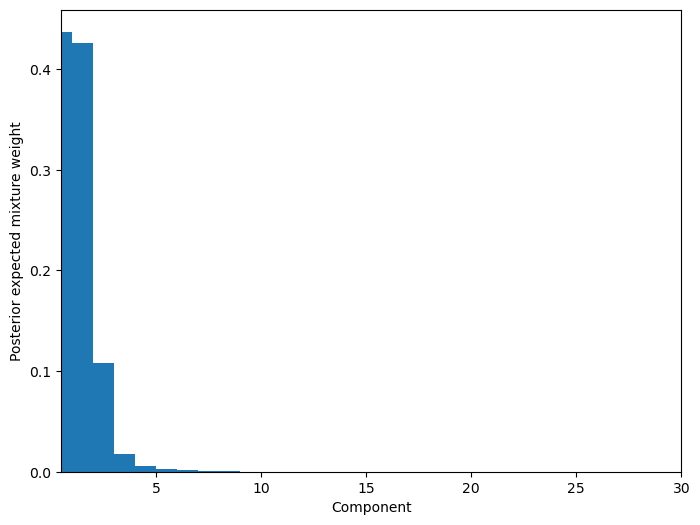

In [461]:
fig, ax = plt.subplots(figsize=(8, 6))

plot_w = np.arange(K) + 1

ax.bar(plot_w - 0.5, trace.posterior["w"].mean(("chain", "draw")), width=1.0, lw=0)

ax.set_xlim(0.5, K)
ax.set_xlabel("Component")

ax.set_ylabel("Posterior expected mixture weight");

We see that only three mixture components have appreciable posterior expected weights, so we conclude that truncating the Dirichlet process to thirty components has not appreciably affected our estimates.

We now compute and plot our posterior density estimate.

In [479]:
x_plot = xr.DataArray(np.linspace(-3, 3, 250), dims=["plot"])
post_pdf_contribs = xr.apply_ufunc(
    sp.stats.norm.pdf,
    x_plot,
    trace.posterior["mu"],
    1.0 / np.sqrt(trace.posterior["lambda_"] * trace.posterior["tau"]),
)

post_pdfs = (trace.posterior["w"] * post_pdf_contribs).sum(dim=("component"))

post_pdf_quantiles = post_pdfs.quantile([0.1, 0.9], dim=("chain", "draw"))

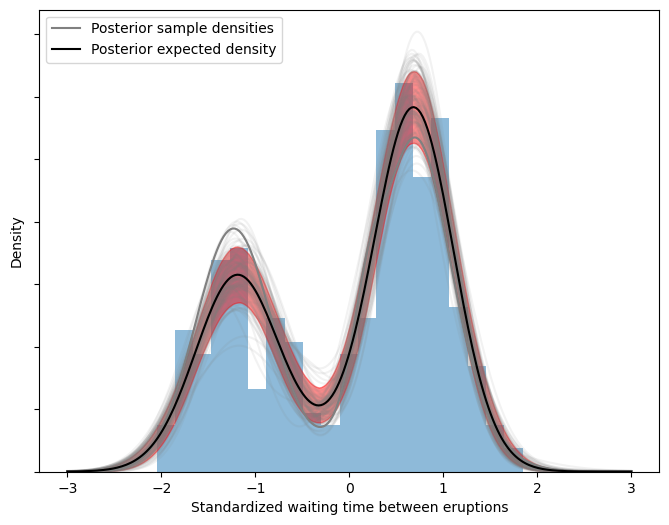

In [482]:
fig, ax = plt.subplots(figsize=(8, 6))

n_bins = 20
ax.hist(old_faithful_df.std_waiting.values, bins=n_bins, density=True, color="C0", lw=0, alpha=0.5)

ax.fill_between(
    x_plot,
    post_pdf_quantiles.sel(quantile=0.1),
    post_pdf_quantiles.sel(quantile=0.9),
    color="red",
    alpha=0.45,
)
ax.plot(x_plot, post_pdfs.sel(chain=0, draw=0), c="gray", label="Posterior sample densities")
ax.plot(
    x_plot,
    az.extract(post_pdfs, var_names="x", num_samples=100),
    c="gray",
    alpha=0.1,
)
ax.plot(x_plot, post_pdfs.mean(dim=("chain", "draw")), c="k", label="Posterior expected density")

ax.set_xlabel("Standardized waiting time between eruptions")

ax.set_yticklabels([])
ax.set_ylabel("Density")

ax.legend(loc=2);

As above, we can decompose this density estimate into its (weighted) mixture components.



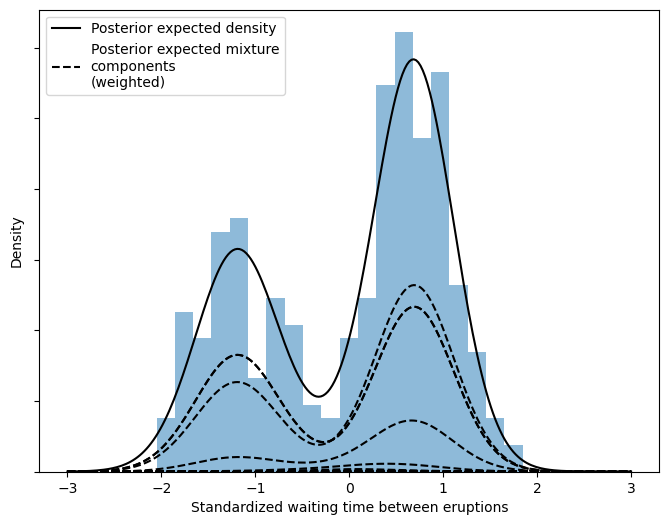

In [483]:
fig, ax = plt.subplots(figsize=(8, 6))

n_bins = 20
ax.hist(old_faithful_df.std_waiting.values, bins=n_bins, density=True, color="C0", lw=0, alpha=0.5)

ax.plot(x_plot, post_pdfs.mean(dim=("chain", "draw")), c="k", label="Posterior expected density")
ax.plot(
    x_plot,
    (trace.posterior["w"] * post_pdf_contribs).mean(dim=("chain", "draw")).sel(component=0),
    "--",
    c="k",
    label="Posterior expected mixture\ncomponents\n(weighted)",
)
ax.plot(
    x_plot,
    (trace.posterior["w"] * post_pdf_contribs).mean(dim=("chain", "draw")).T,
    "--",
    c="k",
)

ax.set_xlabel("Standardized waiting time between eruptions")

ax.set_yticklabels([])
ax.set_ylabel("Density")

ax.legend(loc=2);

# Example with user inputs for alpha and # components

In [519]:
try:
    old_faithful_df = pd.read_csv(os.path.join("..", "data", "old_faithful.csv"))
except FileNotFoundError:
    old_faithful_df = pd.read_csv(pm.get_data("old_faithful.csv"))

In [520]:
old_faithful_df["std_waiting"] = (
    old_faithful_df.waiting - old_faithful_df.waiting.mean()
) / old_faithful_df.waiting.std()

old_faithful_df.head()

,eruptions,waiting,std_waiting
0,3.600,79,0.596025
1,1.800,54,-1.242890
2,3.333,74,0.228242
3,2.283,62,-0.654437
4,4.533,85,1.037364


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

n_bins = 20
ax.hist(old_faithful_df.std_waiting, bins=n_bins, color="C0", lw=0, alpha=0.5)

ax.set_xlabel("Standardized waiting time between eruptions")
ax.set_ylabel("Number of eruptions");

In [ ]:
N = old_faithful_df.shape[0]
K = 30

In [ ]:
def stick_breaking(beta):
    portion_remaining = pt.concatenate([[1], pt.extra_ops.cumprod(1 - beta)[:-1]])
    return beta * portion_remaining

In [ ]:
with pm.Model(coords={"component": np.arange(K), "obs_id": np.arange(N)}) as model:
    #prior on alpha (number of components) - we don't know how concentrated it should be
    alpha = pm.Gamma("alpha", 1.0, 1.0)
    
    # stick-breaking calculation
    beta = pm.Beta("beta", 1.0, alpha, dims="component")
    w = pm.Deterministic("w", stick_breaking(beta), dims="component")

    #prior on tau, related to concentration of components
    tau = pm.Gamma("tau", 1.0, 1.0, dims="component")
    lambda_ = pm.Gamma("lambda_", 10.0, 1.0, dims="component")
    
    #base distribution
    mu = pm.Normal("mu", 0, tau=lambda_ * tau, dims="component")
    
    # final mixture, where each component has precision lambda*tau
    # samples from components reflect observed data
    obs = pm.NormalMixture(
        "obs", w, mu, tau=lambda_ * tau, observed=old_faithful_df.std_waiting.values, dims="obs_id"
    )

In [ ]:
#takes ~30 minutes to run
with model:
    trace = pm.sample(
        tune=2500,
        init="advi",
        target_accept=0.975,
        random_seed=RANDOM_SEED,
    )

In [ ]:
az.plot_trace(trace, var_names=["alpha"]);

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

plot_w = np.arange(K) + 1

ax.bar(plot_w - 0.5, trace.posterior["w"].mean(("chain", "draw")), width=1.0, lw=0)

ax.set_xlim(0.5, K)
ax.set_xlabel("Component")

ax.set_ylabel("Posterior expected mixture weight");

In [ ]:
x_plot = xr.DataArray(np.linspace(-3, 3, 250), dims=["plot"])
post_pdf_contribs = xr.apply_ufunc(
    sp.stats.norm.pdf,
    x_plot,
    trace.posterior["mu"],
    1.0 / np.sqrt(trace.posterior["lambda_"] * trace.posterior["tau"]),
)

post_pdfs = (trace.posterior["w"] * post_pdf_contribs).sum(dim=("component"))

post_pdf_quantiles = post_pdfs.quantile([0.1, 0.9], dim=("chain", "draw"))

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

n_bins = 20
ax.hist(old_faithful_df.std_waiting.values, bins=n_bins, density=True, color="C0", lw=0, alpha=0.5)

ax.fill_between(
    x_plot,
    post_pdf_quantiles.sel(quantile=0.1),
    post_pdf_quantiles.sel(quantile=0.9),
    color="red",
    alpha=0.45,
)
ax.plot(x_plot, post_pdfs.sel(chain=0, draw=0), c="gray", label="Posterior sample densities")
ax.plot(
    x_plot,
    az.extract(post_pdfs, var_names="x", num_samples=100),
    c="gray",
    alpha=0.1,
)
ax.plot(x_plot, post_pdfs.mean(dim=("chain", "draw")), c="k", label="Posterior expected density")

ax.set_xlabel("Standardized waiting time between eruptions")

ax.set_yticklabels([])
ax.set_ylabel("Density")

ax.legend(loc=2);

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

n_bins = 20
ax.hist(old_faithful_df.std_waiting.values, bins=n_bins, density=True, color="C0", lw=0, alpha=0.5)

ax.plot(x_plot, post_pdfs.mean(dim=("chain", "draw")), c="k", label="Posterior expected density")
ax.plot(
    x_plot,
    (trace.posterior["w"] * post_pdf_contribs).mean(dim=("chain", "draw")).sel(component=0),
    "--",
    c="k",
    label="Posterior expected mixture\ncomponents\n(weighted)",
)
ax.plot(
    x_plot,
    (trace.posterior["w"] * post_pdf_contribs).mean(dim=("chain", "draw")).T,
    "--",
    c="k",
)

ax.set_xlabel("Standardized waiting time between eruptions")

ax.set_yticklabels([])
ax.set_ylabel("Density")

ax.legend(loc=2);

# sklearn.mixture.BayesianGaussianMixture

In [548]:
from sklearn.mixture import BayesianGaussianMixture

/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


[]

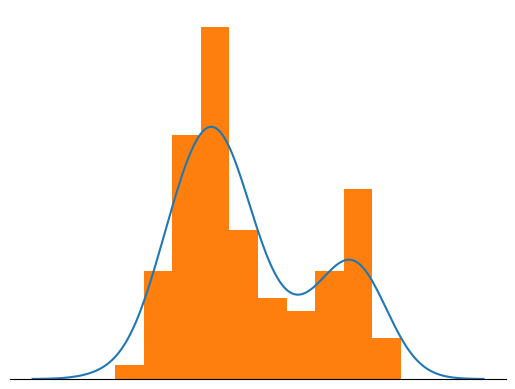

In [559]:
#create and visaulize fake data
data = np.array(list(np.random.normal(1,1,70)) + list(np.random.normal(5,1,30)))
weights = np.random.uniform(0,1,len(data))
weights /= sum(weights)
stds = np.random.uniform(0.5,1,len(data))

#plot
fig, ax = plt.subplots(1,1)
sns.kdeplot(data, ax=ax)
plt.hist(data, density=True)

#format
ax.spines[['left', 'right', 'top']].set_visible(False)
ax.get_yaxis().set_visible(False)
ax.set_xticks([])

In [691]:
min_std = 1
n_components = 0

while min_std > 0.01:
    n_components += 1
    bgm = BayesianGaussianMixture(
        n_components=n_components,
        covariance_type='spherical',
        # covariance_prior=stds,
        weight_concentration_prior_type='dirichlet_process',
        # weight_concentration_prior=0.5,
        # mean_prior=data,
    )
    bgm.fit(data.reshape(-1, 1))
    min_std = min(bgm.fit(data.reshape(-1,1)).weights_)
print(n_components)

4


In [689]:
df_plot = pd.DataFrame(columns=['mean', 'std', 'weight'])
df_plot['mean'] = bgm.means_.flatten()
df_plot['std'] = bgm.covariances_.flatten()
df_plot['weight'] = bgm.weights_.flatten()
df_plot = df_plot.sort_values(by='weight', ascending=False)

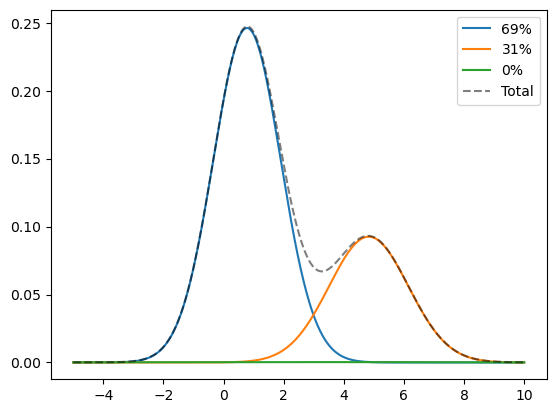

In [690]:
from scipy.stats import norm
fig, ax = plt.subplots(1,1)

xvals = np.linspace(-5,10,1_000)
yvals_total = np.zeros_like(xvals)

for i in df_plot.index:
    mean, std, weight = df_plot.loc[i]
    yvals = norm.pdf(xvals, mean, std)*weight
    yvals_total += yvals
    ax.plot(xvals, yvals, label=f"{int(np.round(weight*100,0))}%");

ax.plot(xvals, yvals_total, label='Total', color='black', linestyle='--', alpha=0.5)
ax.legend()

# DPGMM textbook example

In [ ]:
#pull ECCs for steel
filepath = '../../EPDsFromEC3/EPD_Output/EPDs_steelstructural_2025-01-09.xlsx'
dft = pd.read_excel(filepath)
data = dft['ecc'].dropna().values

In [ ]:
# Generate some univariate data
np.random.seed(42)
# data = np.concatenate([np.random.normal(-5, 1, 200), np.random.normal(5, 2, 200)])

# Define a Dirichlet Process Gaussian Mixture Model
dpgmm = BayesianGaussianMixture(n_components=10, weight_concentration_prior_type='dirichlet_process', 
                                weight_concentration_prior=1.0)

# Fit the model to the data
dpgmm.fit(data.reshape(-1, 1))

# Predict cluster labels
labels = dpgmm.predict(data.reshape(-1, 1))

# Show the mixture components (means, covariances, weights)
fig, ax = plt.subplots(1,1, figsize=(6,2))

xvals = np.linspace(-10,12, 1_000)
yvals_total = np.zeros_like(xvals)
for mean, std, weight in zip(dpgmm.means_, dpgmm.covariances_, dpgmm.weights_):
    mean = mean[0]
    std = np.sqrt(std[0][0])
    yvals = norm.pdf(xvals, mean, std)*weight
    yvals_total += yvals
    
    label = int(np.round(weight,2)*100)
    if label > 0:
        ax.plot(xvals, yvals, label=f"{label}%")
    else:
        ax.plot(xvals, yvals)
        

ax.plot(xvals, yvals_total, color='black', linestyle='--', label='Total')
ax.legend()

In [ ]:
# Simulated univariate data (assuming two main clusters for simplicity)
np.random.seed(42)
# data = np.concatenate([np.random.normal(-5, 1, 200), np.random.normal(5, 2, 200)])

# Hyperparameters for your prior
bw = 0.9*min([np.quantile(data,0.75)-np.quantile(data,0.25), np.std(data)])*len(data)**-0.2

alpha = 10  # Concentration parameter (higher = more clusters)
mean_prior = np.mean(data)  # Desired average of the PDF
mean_confidence = np.std(data)  # High confidence in the mean (tight prior)
# sigma_prior = 10  # Prior for the standard deviation of the means
bandwidth_prior = 5  # Rough estimate for the bandwidth (sigma) of the kernels
n_components = 20


# alpha = 1.0  # Concentration parameter (higher = more clusters)
# mean_prior = 0  # Desired average of the PDF
# mean_confidence = 10  # High confidence in the mean (tight prior)
# sigma_prior = 10  # Prior for the standard deviation of the means
# bandwidth_prior = 5  # Rough estimate for the bandwidth (sigma) of the kernels
# n_components = 10

# PyMC model setup
with pm.Model() as model:
    
    # Concentration parameter (alpha) for the Dirichlet Process
    concentration = pm.Gamma('alpha', alpha=alpha, beta=1.0)
    
    # Base measure (mean and bandwidths are drawn from here)
    base_mean = pm.Normal('base_mean', mu=mean_prior, sigma=mean_confidence)
    base_bandwidth = pm.HalfNormal('base_bandwidth', sigma=bandwidth_prior)
    
    # Stick-breaking process (the DP process that assigns weights to components)
    # Note: We're simplifying to use Dirichlet here. In a more complex model, this would adapt dynamically.
    # weights = pm.Dirichlet('weights', a=np.ones(1))  # Starting with one component for simplicity

    weights = pm.Dirichlet('weights', a=np.ones(n_components)/n_components)

    # Component means and variances (variances represent bandwidths)
    means = pm.Normal('means', mu=base_mean, sigma=0.5, shape=(n_components,))
    variances = pm.HalfNormal('variances', sigma=base_bandwidth, shape=(n_components,))
    
    # Mixture model using the mixture of Gaussians
    # We need to sum across components, weighting each by its mixture weight
    obs = pm.NormalMixture('obs', w=weights, mu=means, sigma=variances, observed=data)
    
    # Sample posterior
    trace = pm.sample(1000)



In [ ]:
# Visualize posterior of the parameters
pm.plot_trace(trace, var_names=['alpha', 'means', 'variances'])
plt.show()

In [ ]:
# Plot a few posterior samples of the KDE
xvals = np.linspace(min(data)-3*bw, max(data)+3*bw, 1_000)
sampled_means = trace['posterior']['means']
sampled_variances = trace['posterior']['variances']
weights_samples = trace['posterior']['weights']

fig, ax = plt.subplots(1,1, figsize=(10,6))

arrays = np.zeros_like(xvals).reshape(1,-1)

I = sampled_means.shape[0]
J = sampled_means.shape[1]
for i in range(I):  # Go through all chains
    # Sum across components for the KDE, weighting by component weights
    for j in range(int(J/2),J): # second half of each chain
        means = sampled_means[i,j].values
        stds = np.sqrt(sampled_variances[i,j].values)
        yvals = np.zeros_like(xvals)
        for mean, std in zip(means, stds):
            yvals += norm.pdf(xvals, loc=mean, scale=std)/len(means)
        ax.plot(xvals, yvals, alpha=0.05, color='black')
        
        #add yvals to array
        if sum(sum(arrays)) > 0:
            arrays = np.append(arrays, yvals.reshape(1,-1), axis=0)
        else:
            arrays[0] += yvals
            
sns.kdeplot(data, ax=ax)
ax.set_title('Posterior Samples of KDE (Dirichlet Process Prior)')
# ax.legend()


In [ ]:
print(f"Mean Actual: {np.mean(means)}")
print(f"Mean Input:  {mean_prior}")
print(f"Mean Act/In: {np.mean(means)/mean_prior}")
print('')
print(f"StDv Actual: {np.std(means)}")
print(f"StDv Input:  {mean_confidence}")
print(f"StDv Act/In: {np.std(means)/mean_confidence}")


In [ ]:
means = []
for array in arrays:
    means.append(sum(xvals*array)/sum(array))

plt.hist(means, bins=100);

In [ ]:
fig, axes = plt.subplots(2,1, figsize=(6,2))
pdf = array[0]
xstep = xvals[1]-xvals[0]
cdf = np.cumsum(pdf*xstep)

ax = axes[0]
ax.plot(xvals, pdf)

ax = axes[1]
ax.plot(xvals, cdf)

In [ ]:
# mean = 0
# std = 1
# xvals = np.linspace(-3,3,1_000)

# yvals = norm.pdf(xvals, mean, std)

# fig, ax = plt.subplots()
# ax.plot(xvals, yvals)

In [ ]:
# min_std = 1
# n_components = 0

# while min_std > 0.01:
#     n_components += 1
#     bgm = BayesianGaussianMixture(
#         n_components=n_components,
#         covariance_type='spherical',
#         # covariance_prior=stds,
#         weight_concentration_prior_type='dirichlet_process',
#         # weight_concentration_prior=0.5,
#         # mean_prior=data,
#     )
#     bgm.fit(data.reshape(-1, 1))
#     min_std = min(bgm.fit(data.reshape(-1,1)).weights_)
# print(n_components)

# Further exploring textbook example

In [ ]:
# Generate some univariate data
np.random.seed(42)
# data = np.concatenate([np.random.normal(-5, 1, 200), np.random.normal(5, 2, 200)])

# Define a Dirichlet Process Gaussian Mixture Model
dpgmm = BayesianGaussianMixture(n_components=10, weight_concentration_prior_type='dirichlet_process', 
                                weight_concentration_prior=1.0)

# Fit the model to the data
dpgmm.fit(data.reshape(-1, 1))

#create dataframe and get priors

import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
from scipy.stats import norm

# Simulated univariate data (assuming two main clusters for simplicity)
np.random.seed(42)
# data = np.concatenate([np.random.normal(-5, 1, 200), np.random.normal(5, 2, 200)])

# Hyperparameters for your prior
alpha = 1.0  # Concentration parameter (higher = more clusters)
mean_prior = 0  # Desired average of the PDF
mean_confidence = 10  # High confidence in the mean (tight prior)
sigma_prior = 10  # Prior for the standard deviation of the means
bandwidth_prior = 5  # Rough estimate for the bandwidth (sigma) of the kernels

n_components = 5
base_mean = np.quantile(data,np.arange(1/(n_components+1), 0.99, 1/(n_components+1)))

# PyMC model setup
with pm.Model() as model:
    
    # Concentration parameter (alpha) for the Dirichlet Process
    concentration = pm.Gamma('alpha', alpha=alpha, beta=1.0)
    
    # Base measure (mean and bandwidths are drawn from here)
    base_mean = base_mean
    # base_mean = pm.Normal('base_mean', mu=mean_prior, sigma=mean_confidence)
    base_bandwidth = pm.HalfNormal('base_bandwidth', sigma=bandwidth_prior)
    
    # Stick-breaking process (the DP process that assigns weights to components)
    # Note: We're simplifying to use Dirichlet here. In a more complex model, this would adapt dynamically.
    weights = pm.Dirichlet('weights', a=np.ones(1))  # Starting with one component for simplicity
    
    # Component means and variances (variances represent bandwidths)
    means = pm.Normal('means', mu=base_mean, sigma=0.5, shape=(n_components,))
    variances = pm.HalfNormal('variances', sigma=base_bandwidth, shape=(n_components,))
    
    # Mixture model using the mixture of Gaussians
    # We need to sum across components, weighting each by its mixture weight
    obs = pm.NormalMixture('obs', w=weights, mu=means, sigma=variances, observed=data)
    
    # Sample posterior
    trace = pm.sample(2000)


In [ ]:
# Visualize posterior of the parameters
pm.plot_trace(trace)
plt.show()



In [ ]:
# Plot a few posterior samples of the KDE
xvals = np.linspace(min(data)-3*bw, max(data)+3*bw, 1_000)
sampled_means = trace['posterior']['means']
sampled_variances = trace['posterior']['variances']
weights_samples = trace['posterior']['weights']

fig, ax = plt.subplots(1,1, figsize=(10,6))

arrays = np.zeros_like(xvals).reshape(1,-1)

I = sampled_means.shape[0]
J = sampled_means.shape[1]
for i in range(I):  # Go through all chains
    # Sum across components for the KDE, weighting by component weights
    for j in range(int(J/2),J): # second half of each chain
        means = sampled_means[i,j].values
        stds = np.sqrt(sampled_variances[i,j].values)
        yvals = np.zeros_like(xvals)
        for mean, std in zip(means, stds):
            yvals += norm.pdf(xvals, loc=mean, scale=std)/len(means)
        ax.plot(xvals, yvals, alpha=0.05, color='black')
        
        #add yvals to array
        if sum(sum(arrays)) > 0:
            arrays = np.append(arrays, yvals.reshape(1,-1), axis=0)
        else:
            arrays[0] += yvals
            
sns.kdeplot(data, ax=ax)
ax.set_title('Posterior Samples of KDE (Dirichlet Process Prior)')
# ax.legend()


# DIY attempt that I ended up running with

In [ ]:
#pull ECCs for steel
filepath = '../../EPDsFromEC3/EPD_Output/EPDs_steelstructural_2025-01-09.xlsx'
dft = pd.read_excel(filepath)
data = dft['ecc'].dropna().values

In [ ]:
%%time
#initialize variables
nruns = 1_000
granularity = 999
iqr = np.quantile(data, 0.75) - np.quantile(data, 0.25)

# confidence
confidence_weights = 0.6 #proportions of weights that should not be changed. Can also be array of len(data)
bw = 0.9 * min([np.std(data), 1.35*iqr]) * len(data)**-0.2 #product level uncertainty. This can be an array of len(data)
target_tol = np.std(data) #standard deviation of target mean
represented = 0.6 # how much emissions data is represented in this dataset

#priors
target_mean = np.quantile(data, 0.5)
starting_weights = np.zeros_like(data) + 1/len(data)
expected_value0 = sum(data*starting_weights)
xvals = np.linspace(
    min(min(data)-5*bw, target_mean-target_tol*5), 
    max(max(data)+5*bw, target_mean+target_tol*5),
    granularity
)
totals = np.zeros_like(xvals, shape=(nruns,len(xvals)))


meta_means = []
meta_weights = []

#collect metadata
percs_included = []

lst = []
lst2 = []

for i in tqdm(range(nruns), desc='Loading....'):
    # remove unrepresented data
    weights = starting_weights*represented

    # randomly pick ECC values acccording to mean and product-level uncertainty. Make sure we don't pull any negative values
    means = np.random.normal(data, bw) #random value with each ECC as the mean and bandwidth
    while min(means) < 0:
        ind = np.where(means==min(means))[0][0]
        means[ind] = np.random.normal(data[ind], bw)


    # add new values to means to represent unrepresented data
    target = np.random.normal(target_mean, target_tol)
    while target < 0:
        target = np.random.normal(target_mean, target_tol)
    
    n = 10
    if target >= sum(means*weights)/sum(weights):
        new_means = abs(np.random.normal(0,1,n))
        new_weights = np.random.uniform(0,1,n)
        new_weights *= (1-represented)/sum(new_weights)
        new_means /= sum(new_means*new_weights)/sum(new_weights) #normalize so weighted average is 1
        factor = (target-sum(means*weights)/sum(weights))*represented/(1-represented) #think of them as moment arms. distance = weighted averages, force = represented
        new_means = target + new_means*factor
    elif target / (sum(means*weights)/sum(weights)) > represented: # positive values can get to our target
        new_means = np.random.uniform(0, 1, n)
        new_weights = np.random.uniform(0,1,n)
        new_weights *= (1-represented)/sum(new_weights)
        goal_avg = -(((sum(means*weights)/sum(weights)-target)*represented) / (1-represented) - target)
        current_avg = sum(new_means*new_weights)/sum(new_weights)
        factor = goal_avg/current_avg
        new_means *= factor
    else: # positive values cannot help achieve our target, add big lump at zero
        new_means = np.array([0])
        new_weights = np.array([1-represented])
        

    
    weights = np.concatenate((weights, new_weights))
    means = np.concatenate((means, new_means))
    

    # separate into lower and higher than target. Preserve order in case weights are custom
    weights *= confidence_weights
    means_lo, weights_lo = np.array([(mean, weight) for (mean, weight) in zip(means, weights) if mean < target]).T
    means_hi, weights_hi = np.array([(mean, weight) for (mean, weight) in zip(means, weights) if mean >= target]).T

    #pare down existing weights by our confidence in input weights
    leftover_weight = 1-sum(weights)

    # Get random values that will apply to the low and high means
    # prox_lo = -1
    # while prox_lo < 0:
    rand_lo = np.random.uniform(0,1,len(means_lo))
    rand_lo *= leftover_weight/sum(rand_lo)

    rand_hi = np.random.uniform(0,1,len(means_hi))
    rand_hi *= leftover_weight/sum(rand_hi)

    # find out weighted mean if all leftover_weight goes to low or if all goes to high
    lo = sum(means_lo*(rand_lo + weights_lo)) + sum(means_hi*weights_hi)
    hi = sum(means_hi*(rand_hi + weights_hi)) + sum(means_lo*weights_lo)

    # # find the proximity of the target relative to the weighted average of lower values. randomize according to target tolerance.
    prox_lo = (target-lo)/(hi-lo)
    if prox_lo < 0:
        prox_lo = 0
    elif prox_lo > 1:
        prox_lo = 1

    # # adjust weights according to our randomized proximity value
    weights_lo = weights_lo + rand_lo*(1-prox_lo)
    weights_hi = weights_hi + rand_hi*prox_lo
    
    # # put low and high weights and means back into the same array
    weights = np.concatenate((weights_lo, weights_hi))
    means = np.concatenate((means_lo, means_hi))

    meta_weights += list(weights)
    meta_means += list(means)
    
    lst.append(sum(means*weights)/sum(weights))

    #evaluate all means
    yvals = norm.pdf(xvals.reshape(-1,1), means, bw)*weights
    totals[i] = sum(yvals.T)
    totals[i] /= sp.integrate.trapezoid(totals[i], xvals)

In [ ]:
%%time
q25 = np.quantile(totals, 0.25, axis=0)
q50 = np.quantile(totals, 0.50, axis=0)
q75 = np.quantile(totals, 0.75, axis=0)

color = 'tab:red'

fig, ax = plt.subplots(1,1)

# plot simulations
ax.plot(xvals, totals.T, alpha=0.01, color='black');
ax.plot(xvals, q50, alpha=0.5, color='gray', label=f"{nruns} simulations");

# plot quartiles
ax.plot(xvals, q50/sp.integrate.trapezoid(q50, xvals), color=color, label='Median');
ax.plot(xvals, q25, color=color, linestyle='--', label='IQR');
ax.plot(xvals, q75, color=color, linestyle='--');
ax.fill_between(xvals, q25, q75, color=color, alpha=0.5)

#plot regular kde applied to data
sns.kdeplot(data=data, bw_method='silverman', label='Regular KDE')

# format
ax.get_yaxis().set_visible(False)
ax.get_xaxis().set_visible(True)
ax.legend();
ax.spines[['top', 'right', 'left']].set_visible(False)
# ax.set_ylim(0,);
# ax.set_xlim(0,);

ax.vlines(x=0, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='black');
ax.hlines(y=0, xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='black');


In [ ]:
fig, ax = plt.subplots()

ax.scatter(meta_means, meta_weights, alpha=0.01)
ax.vlines(target_mean, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='black');
ax.hlines(0, xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='black');

ax.set_xlabel('means');
ax.set_ylabel('weights');

In [ ]:
target_mean = 1.5


In [ ]:
# remove unrepresented data

weights = starting_weights*represented

# randomly pick ECC values acccording to mean and product-level uncertainty. Make sure we don't pull any negative values
means = np.random.normal(data, bw) #random value with each ECC as the mean and bandwidth
while min(means) < 0:
    ind = np.where(means==min(means))[0][0]
    means[ind] = np.random.normal(data[ind], bw)


# add new values to means to represent unrepresented data
target = np.random.normal(target_mean, target_tol)
target = target_mean
while target < 0:
    target = np.random.normal(target_mean, target_tol)

n = 10
if target >= sum(means*weights)/sum(weights):
    new_means = abs(np.random.normal(0,1,n))
    new_weights = np.random.uniform(0,1,n)
    new_weights *= (1-represented)/sum(new_weights)
    new_means /= sum(new_means*new_weights)/sum(new_weights) #normalize so weighted average is 1
    factor = (target-sum(means*weights)/sum(weights))*represented/(1-represented) #think of them as moment arms. distance = weighted averages, force = represented
    new_means = target + new_means*factor
elif target / (sum(means*weights)/sum(weights)) > represented: # positive values can get to our target
    new_means = np.random.uniform(0, 1, n)
    new_weights = np.random.uniform(0,1,n)
    new_weights *= (1-represented)/sum(new_weights)
    goal_avg = -(((sum(means*weights)/sum(weights)-target)*represented) / (1-represented) - target)
    current_avg = sum(new_means*new_weights)/sum(new_weights)
    factor = goal_avg/current_avg
    new_means *= factor
else: # positive values cannot help achieve our target, add big lump at zero
    new_means = np.array([0])
    new_weights = np.array([1-represented])



In [ ]:


print('new means')
print((target-sum(new_means*factor*new_weights)/sum(new_weights))*(1-represented))
print('')

print('existing means')
print((sum(means*weights)/sum(weights)-target)*represented)

In [ ]:
# weights = np.concatenate((weights, new_weights))
# means = np.concatenate((means, new_means))


# # separate into lower and higher than target. Preserve order in case weights are custom
# weights *= confidence_weights
# means_lo, weights_lo = np.array([(mean, weight) for (mean, weight) in zip(means, weights) if mean < target]).T
# means_hi, weights_hi = np.array([(mean, weight) for (mean, weight) in zip(means, weights) if mean >= target]).T

# #pare down existing weights by our confidence in input weights
# leftover_weight = 1-sum(weights)

# # Get random values that will apply to the low and high means
# rand_lo = np.random.uniform(0,1,len(means_lo))
# rand_lo *= leftover_weight/sum(rand_lo)

# rand_hi = np.random.uniform(0,1,len(means_hi))
# rand_hi *= leftover_weight/sum(rand_hi)

# # find out weighted mean if all leftover_weight goes to low or if all goes to high
# lo = sum(means_lo*(rand_lo + weights_lo)) + sum(means_hi*weights_hi)
# hi = sum(means_hi*(rand_hi + weights_hi)) + sum(means_lo*weights_lo)

# # # find the proximity of the target relative to the weighted average of lower values. randomize according to target tolerance.
# prox_lo = (target-lo)/(hi-lo)

# # # adjust weights according to our randomized proximity value
# weights_lo = weights_lo + rand_lo*(1-prox_lo)
# weights_hi = weights_hi + rand_hi*prox_lo

# # # put low and high weights and means back into the same array
# weights = np.concatenate((weights_lo, weights_hi))
# means = np.concatenate((means_lo, means_hi))

# meta_weights += list(weights)
# meta_means += list(means)


# #evaluate all means
# yvals = norm.pdf(xvals.reshape(-1,1), means, bw)*weights
# totals[i] = sum(yvals.T)
# totals[i] /= sp.integrate.trapezoid(totals[i], xvals)

1. Start by randomly generating ECC values according to how much data is missing (think confidence intervals)
1. Start with uniform weights
1. Then, shuffle weights according to how much data is missing
1. Keep shuffled values that move us closer to the target and get rid of changes that move us farther away
1. Assess whether to accept the final changes according to the target value and acceptance criteria (st dev of target mean)
1. Rerun until we accept.
1. Do it again 1000x